Лабораторная работа №2. Вывод символов на экран дисплея.

---





In [1]:
import random as rd
import pandas as pd
import math

Variant = 14
rd.seed(Variant)

Str1 = 'qwertyuioplkjhgfdsazxcvbnmQWERTYUIOPASDFGHJKLZXCVBNM'
N = rd.randint(20, 40)

s1 = ''
for i in range(N):
    s1 += Str1[rd.randint(0, len(Str1) - 1)]

D = '!@#$%&*+:;|'[rd.randint(0, 10)]
N1 = rd.randint(3, 30)
N2 = int(N1 * (N1 + 1) / 2)

if (int(N2 / N1) - math.floor(N2 / N1)) == 0:
    M = int(N2 / N1)
    K = int(N2 / M)
else:
    M = int(N2 / (N1 + 1))
    K = int(N2 / M)

N4 = rd.randint(123432, 5645634534)

Data = pd.DataFrame({
    'Задание': [1, 2, 3, 4, 5],
    'Параметры': [
        'S=' + s1,
        [D, 'N=' + str(N2), 'M =' + str(M), 'K = ' + str(K)],
        '-',
        'N=' + str(N4),
        '-'
    ]
})

print(Data)


   Задание                  Параметры
0        1  S=FLVHIfsCdaXtJEzRKmmBidg
1        2   [&, N=105, M =7, K = 15]
2        3                          -
3        4               N=3469816182
4        5                          -


1. Разработать программу на языке ассемблера, которая выводит на экран заданную строку
 в обратном порядке.

In [ ]:
format ELF64

public _start
public exit
public print_symb

section '.data' writable
    string db "FLVHIfsCdaXtJEzRKmmBidg"
    str_len = $ - string
    char db 1 ; байтовая ячейка для вывода одного символа

section '.text' executable
    _start:
        mov rcx, str_len ; индекс выводимого символа (байта), начиная с конца строки
        .iter:
            dec rcx
            mov al, [string + rcx] ; сохраняем выводимый символ в al
            push rcx ; запоминаем значение индекса (кладем его в стек)
            call print_symb
            pop rcx
            cmp rcx, 0 ; пока не дошли до нулевого символа строки
            jne .iter
        jmp exit

print_symb:
    mov [char], al ; помещаем байт символа из регистра al в ячейку памяти по адресу char
    mov rax, 1
    mov rdi, 1
    mov rsi, char
    mov rdx, 1
    syscall
    ret ; извлекает адрес возврата из верхушки стека и переходит по нему

exit:
    mov rax, 60
    mov rdi, 0
    syscall


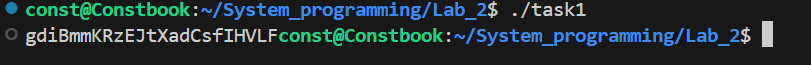

2. Разработать программу на языке ассемблера, в которой заполнить память
 заданными символами, вывести их в виде матрицы по
 символов в строке и
 строк

In [ ]:
format ELF64

public _start
public exit

section '.data' writable
    char db '&'
    nl db 10 ; \n

section '.bss' writable
    buffer rb 120 ; специально аллоцируем буфер для заполнения символами (включая \n)

section '.text' executable
    _start:
        mov al, [char] ; сохраняем наш символ в al
        xor rcx, rcx ; счетчик с 0
        .iter1:
            mov [buffer + rcx], al ; последовательно заполняем предварительно выделенный буфер в памяти нашими символами
            inc rcx
            cmp rcx, 105
            jne .iter1
        xor rbx, rbx ; счетчик с шагом 7 для вывода символов блоками
        .iter2:
            mov rax, 1
            mov rdi, 1
            lea rsi, [buffer + rbx] ; вычисляет динамический адрес и кладет его в rsi
            mov rdx, 7 ; выводим по 7 символов за раз в одной строке
            syscall

            mov rax, 1
            mov rdi, 1
            mov rsi, nl ; \n
            mov rdx, 1
            syscall

            add rbx, 7
            cmp rbx, 105
            jne .iter2
        jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall


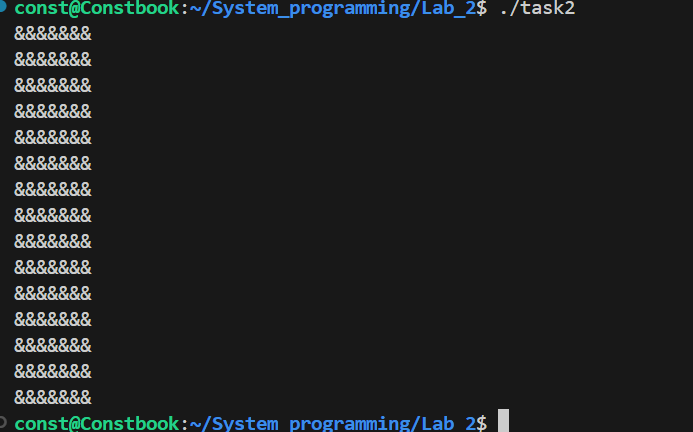

3. В задании 2 вывести символы в виде треугольника.

In [ ]:
format ELF64

public _start
public exit

section '.data' writable
    char db '&'
    nl db 10

section '.bss' writable
    buffer rb 120 ; резервируем буфер для символов
    cur_adr rq 1 ; переменная (8 байт) для хранения текущего адреса чтения из буфера

section '.text' executable
    _start:
        mov al, [char]
        xor rcx, rcx
        .iter1:
            mov [buffer + rcx], al
            inc rcx
            cmp rcx, 105
            jne .iter1
        xor rbx, rbx ; будет хранить количество выводимых символов в каждой строке
        mov rax, buffer
        mov [cur_adr], rax ; инициализируем указатель началом буфера
        .iter2:
            mov rax, 1
            mov rdi, 1
            add [cur_adr], rbx ; сдвигаем указатель вперед на количество выведенных в прошлый раз символов
            mov rsi, [cur_adr] ; адрес начала блока для вывода
            inc rbx ; увеличиваем количество выводимых символов на 1 (для новой строки)
            mov rdx, rbx
            syscall

            mov rax, 1
            mov rdi, 1
            mov rsi, nl
            mov rdx, 1
            syscall

            cmp rbx, 14 ; напечатали ли мы уже строку из 14 символов (последнюю)
            jne .iter2
        jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall


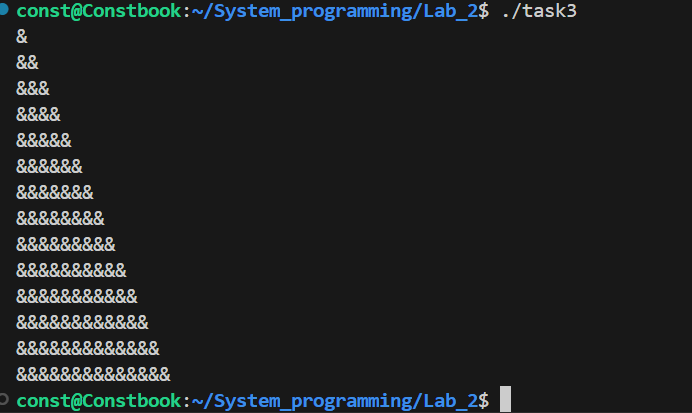

4. Разработать программу на языке ассемблера, в которой для заданного числа
 найти сумму его цифр и вывести результат на экран.

In [ ]:
format ELF64

public _start
public exit

section '.data' writable
    num dd 3469816182 ; беззнаковое представление, укладывается в 32 бита
    ten db 1

section '.bss' writable
    result rb 2 ; буфер для строки, состоящей из цифр ответа (суммы)

section '.text' executable
    _start:
        xor ebx, ebx ; будет аккумулировать сумму цифр числа
        mov ecx, 10
        mov eax, [num] ; кладем делимое в eax (оттуда его будет использовать div)
        .iter1:
            xor edx, edx ; обнуляем edx для корректного считывания делимого
            div ecx ; делит число, хранящееся в edx:eax на число, которое лежит в ecx (10)
            add ebx, edx ; прибавляем к сумме остаток от деления числа на 10
            cmp eax, 0 ; в eax сохраняется результат деления
            jne .iter1
        ; посимвольный вывод ответа
        xor eax, eax
        mov [ten], cl ; теперь делитель должен быть 8-битный
        mov rcx, 2 ; счетчик для вывода цифр суммы
        .iter2:
            dec rcx
            mov ax, bx ; кладем предыдущий результат в ax
            xor ah, ah ; обнуляем ah для корректного считывания делимого
            div [ten] ; делит число в ax на 10, сохраняя результат в al и остаток в ah
            mov bl, al ; сохраняет результат
            add ah, '0' ; к остатку прибавляем '0', получаем ASCII-код цифры числа
            mov [result + rcx], ah ; записываем цифру в буфер с конца
            cmp rcx, 0
            jne .iter2

        mov rax, 1
        mov rdi, 1
        mov rsi, result ; выводим последовательность символов суммы в виде строки
        mov rdx, 2
        syscall
    jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall


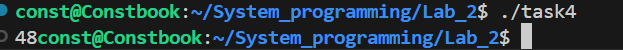

5. Разработать программу аналогичную заданию 4 на языке программирования C. Провести сравнение размеров исполняемых файлов.

In [ ]:
#include <stdio.h>

unsigned int sumOfDigits(unsigned long long num) {
    unsigned int sum = 0;

    while (num > 0) {
        sum += num % 10;
        num /= 10;
    }

    return sum;
}

int main(void) {
    unsigned long long number = 3469816182ULL;

    unsigned int ans = sumOfDigits(number);
    printf("%u\n", ans);
    return 0;
}


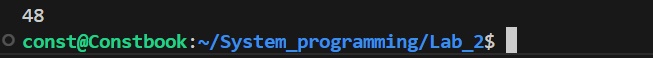